# Linear regression

Import all the modules you will need in this notebook here:

In [165]:
# exercise 0
# Put your solution here!
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
# plots a line given an intercept and a slope
from statsmodels.graphics.regressionplots import abline_plot
import pandas as pd

We continue analysing the `fram` heart disease data.

First load the data, use the name `fram` for the DataFrame variable. Make sure that in the data you loaded the column and row headers are in place. Checkout the summary of the variables using the `describe` method.

In [ ]:
# exercise 1
def get_path(filename):
    import sys
    import os
    prog_name = sys.argv[0]
    if os.path.basename(prog_name) == "__main__.py":   # Running under TMC
        return os.path.join(os.path.dirname(prog_name), "..", "src", filename)
    else:
        return filename
    
# Put your solution here!
fram = pd.read_csv('src/fram.txt', sep='\t')
fram.describe()

,ID,AGE,FRW,SBP,SBP10,DBP,CHOL,CIG,CHD,DEATH,YRS_DTH
count,1394.000000,1394.000000,1394.000000,1394.000000,767.000000,1394.000000,1394.000000,1394.000000,1394.000000,1394.000000,1394.000000
mean,4737.184362,52.431133,105.365136,148.086083,148.040417,90.135581,234.644907,8.029412,1.187948,1.700861,16.219512
std,1073.406896,4.781507,17.752489,28.022062,25.706664,14.226235,46.303822,11.584138,2.615976,3.203132,3.921413
min,1070.000000,45.000000,52.000000,90.000000,94.000000,50.000000,96.000000,0.000000,0.000000,0.000000,1.000000
25%,3890.250000,48.000000,94.000000,130.000000,130.000000,80.000000,200.000000,0.000000,0.000000,0.000000,18.000000
50%,4821.000000,52.000000,103.000000,142.000000,145.000000,90.000000,230.000000,0.000000,0.000000,0.000000,18.000000
75%,5641.750000,56.000000,114.000000,160.000000,160.000000,98.000000,264.000000,20.000000,0.000000,0.000000,18.000000
max,6442.000000,62.000000,222.000000,300.000000,264.000000,160.000000,430.000000,60.000000,10.000000,10.000000,18.000000


Create function `rescale` that takes a Series as parameter. It should center the data and normalize it by dividing
by 2$\sigma$, where $\sigma$ is the standard deviation. Return the rescaled Series.

In [168]:
# exercise 2
# Put your solution here!
def rescale(s):
    centered = s - s.mean()
    return (centered/(2*s.std()))

Add to the DataFrame the scaled versions of all the continuous variables (with function `rescale`). Add small letter `s` in front of the original variable name to get the name of the scaled variable. For instance, `AGE` -> `sAGE`.

In [169]:
# exercise 3
# Put your solution here!
fram["sAGE"] = rescale(fram.AGE)
fram["sFRW"] = rescale(fram.FRW)
fram["sSBP"] = rescale(fram.SBP)
fram["sDBP"] = rescale(fram.DBP)
fram["sCHOL"] = rescale(fram.CHOL)
fram["sCIG"] = rescale(fram.CIG)
# Note: No need to scale the variable SEX

Form a model that predicts systolic blood pressure using weight, gender, and cholesterol level as explanatory variables. Store the fitted model in variable named `fit`.

In [170]:
# exercise 4
# Put your solution here!
fit = smf.ols('SBP ~ sFRW + SEX + sCHOL', data = fram).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     66.37
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           4.13e-40
Time:                        14:39:11   Log-Likelihood:                -6530.4
No. Observations:                1394   AIC:                         1.307e+04
Df Residuals:                    1390   BIC:                         1.309e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     150.0199      0.985    152.336      

Add the variable AGE to the model and inspect the estimates of the coefficients using the `summary` method of the fitted model. Again use the name `fit` for the fitted model. (From now on assume that we always use the name `fit` for the variable of the fitted model.)

In [171]:
# exercise 5
# Put your solution here!
fit = smf.ols('SBP ~ sFRW + SEX + sCHOL + sAGE', data = fram).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     59.39
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           2.44e-46
Time:                        14:39:14   Log-Likelihood:                -6513.6
No. Observations:                1394   AIC:                         1.304e+04
Df Residuals:                    1389   BIC:                         1.306e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     150.1695      0.974    154.221      

How much does the inclusion of age increase the explanatory power of the model? Which variables explain the variance of the target variable most?

***

R^2 w/o age is 0.125, so the cholesterol, gender and weight combine to explain 12.5% of SBP variance. When age is added, now the variables explain 14.6% of SBP variance. Therefore, age increases explantory power by 2.1%. 

Larger abs t-values indicate a stronger association w/ target variable so weight (sFRW) explains the variance the most and far greater than the age, cholesterol, or gender respectively. 
***

Try to add to the model all the interactions with other variables. 

In [172]:
# exercise 6
# Put your solution here!
fit = smf.ols('SBP ~ sFRW + SEX + sCHOL + sAGE + sFRW:sAGE + sFRW:sCHOL + sFRW:sAGE + sFRW:SEX + SEX:sAGE + SEX:sCHOL + sCHOL:sAGE ', data = fram).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     24.52
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           4.92e-43
Time:                        14:39:17   Log-Likelihood:                -6509.9
No. Observations:                1394   AIC:                         1.304e+04
Df Residuals:                    1383   BIC:                         1.310e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           150.5439      1.00

Then visualize the model as the function of weight for the youngest (sAGE=-1.0), middle aged (sAGE=0.0), and oldest (sAGE=1.0) women while assuming the background variables to be centered. Remember to consider the changes in the intercept and in the regression coefficient caused by age. Visualize both the data points and the fitted lines.

<Figure size 1200x800 with 0 Axes>

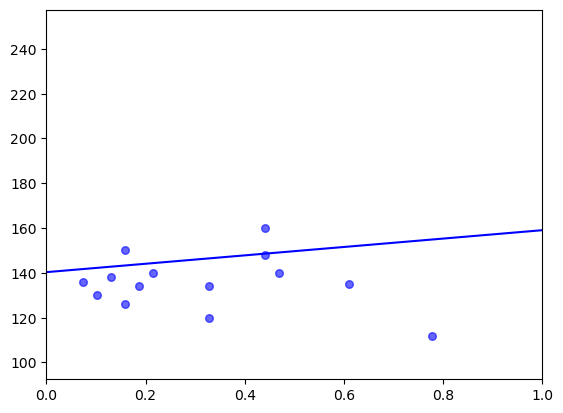

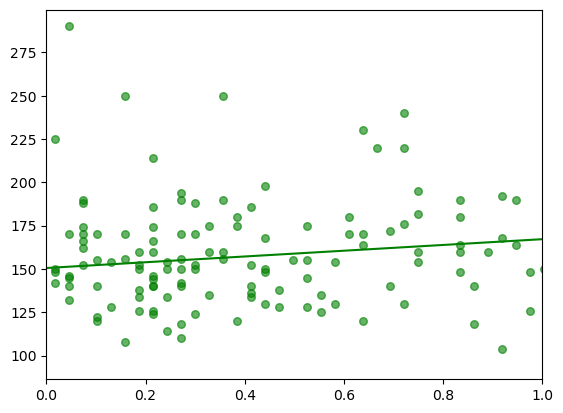

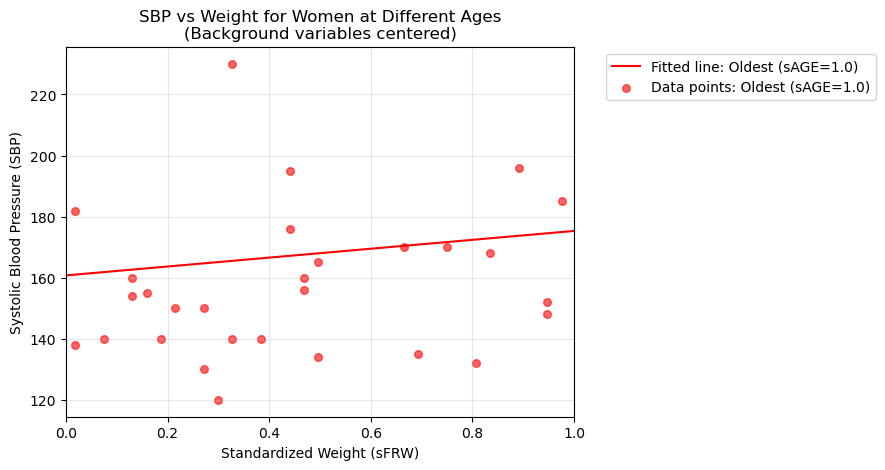

Model equations for women (sCHOL=0):
Youngest (sAGE=-1.0):
  SBP = 140.325 + 18.732 * sFRW

Middle-aged (sAGE=0.0):
  SBP = 150.544 + 16.645 * sFRW

Oldest (sAGE=1.0):
  SBP = 160.763 + 14.558 * sFRW



In [173]:
# exercise 7
# Put your solution here!


# Filter data for women only
women_data = fram[fram['SEX'] == 'female'].copy()

# Create a range of sFRW values for prediction lines
sfrw_range = np.linspace(women_data['sFRW'].min(), women_data['sFRW'].max(), 100)

# Age groups to visualize
age_groups = [-1.0, 0.0, 1.0]
age_labels = ['Youngest (sAGE=-1.0)', 'Middle-aged (sAGE=0.0)', 'Oldest (sAGE=1.0)']
colors = ['blue', 'green', 'red']

# Set up the plot
plt.figure(figsize=(12, 8))

# For each age group, calculate and plot the fitted line using abline_plot
for i, (age, label, color) in enumerate(zip(age_groups, age_labels, colors)):
    # Calculate effective intercept and slope for this age and women (SEX='female')
    intercept = fit.params['Intercept']
    
    # Add age effect to intercept
    if 'sAGE' in fit.params:
        intercept += fit.params['sAGE'] * age
    
    # Main slope for sFRW
    slope = fit.params['sFRW']
    
    # Add interaction effect (sFRW:sAGE changes the slope based on age)
    if 'sFRW:sAGE' in fit.params:
        slope += fit.params['sFRW:sAGE'] * age
    
    # Use abline_plot instead of plt.plot
    abline_plot(intercept, slope, color=color, label=f'Fitted line: {label}')
    
    # Plot actual data points for this age group (approximately)
    # Since sAGE is continuous, we'll show points within a range around each age value
    age_tolerance = 0.3  # Adjust this to include more/fewer points
    age_mask = (women_data['sAGE'] >= age - age_tolerance) & (women_data['sAGE'] <= age + age_tolerance)
    age_subset = women_data[age_mask]
    
    if len(age_subset) > 0:
        plt.scatter(age_subset['sFRW'], age_subset['SBP'], 
                   color=color, alpha=0.6, s=30, 
                   label=f'Data points: {label}')

# Add labels and formatting
plt.xlabel('Standardized Weight (sFRW)')
plt.ylabel('Systolic Blood Pressure (SBP)')
plt.title('SBP vs Weight for Women at Different Ages\n(Background variables centered)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

# Print the model equation for each age group to understand the relationships
print("Model equations for women (sCHOL=0):")
print("=" * 50)

for age, label in zip(age_groups, age_labels):
    # Calculate effective intercept and slope for sFRW at this age
    intercept = fit.params['Intercept']
    
    # Add main effect contributions (SEX='female' is typically encoded as 0, so no contribution)
    if 'sCHOL' in fit.params:
        intercept += fit.params['sCHOL'] * 0  # sCHOL = 0 (centered)
    if 'sAGE' in fit.params:
        intercept += fit.params['sAGE'] * age
    
    # Main slope for sFRW
    sfrw_coeff = fit.params['sFRW']
    
    # Add interaction effects
    if 'sFRW:sAGE' in fit.params:
        sfrw_coeff += fit.params['sFRW:sAGE'] * age
    if 'SEX:sAGE' in fit.params:
        intercept += fit.params['SEX:sAGE'] * age * 0  # SEX='female' typically = 0
    
    print(f"{label}:")
    print(f"  SBP = {intercept:.3f} + {sfrw_coeff:.3f} * sFRW")
    print()

How does the dependence of blood pressure on weight change as a person gets older?
***

The abs slope of the fitted line gets smaller as the sample size's age is older. This indicates that the dependence of blood pressure on a person's weight shrinks as a person grows older. This conclusion makes sense since, as people age, new factors begin to appear and contribute to blood pressure changes making weight less responsibile.  

***

### Even more accurate model

Include the background variable `sCIG` from the data and its interactions. Visualize the model for systolic blood pressure as the function of the most important explanatory variable. Visualize separate lines for the small (-1.0), average (0.0), and large (1.0) values of `sCHOL`. Other variables can be assumed to be at their mean value.

Enhanced Model Summary:
                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     16.50
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           2.99e-40
Time:                        14:39:30   Log-Likelihood:                -6508.6
No. Observations:                1394   AIC:                         1.305e+04
Df Residuals:                    1378   BIC:                         1.313e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept     

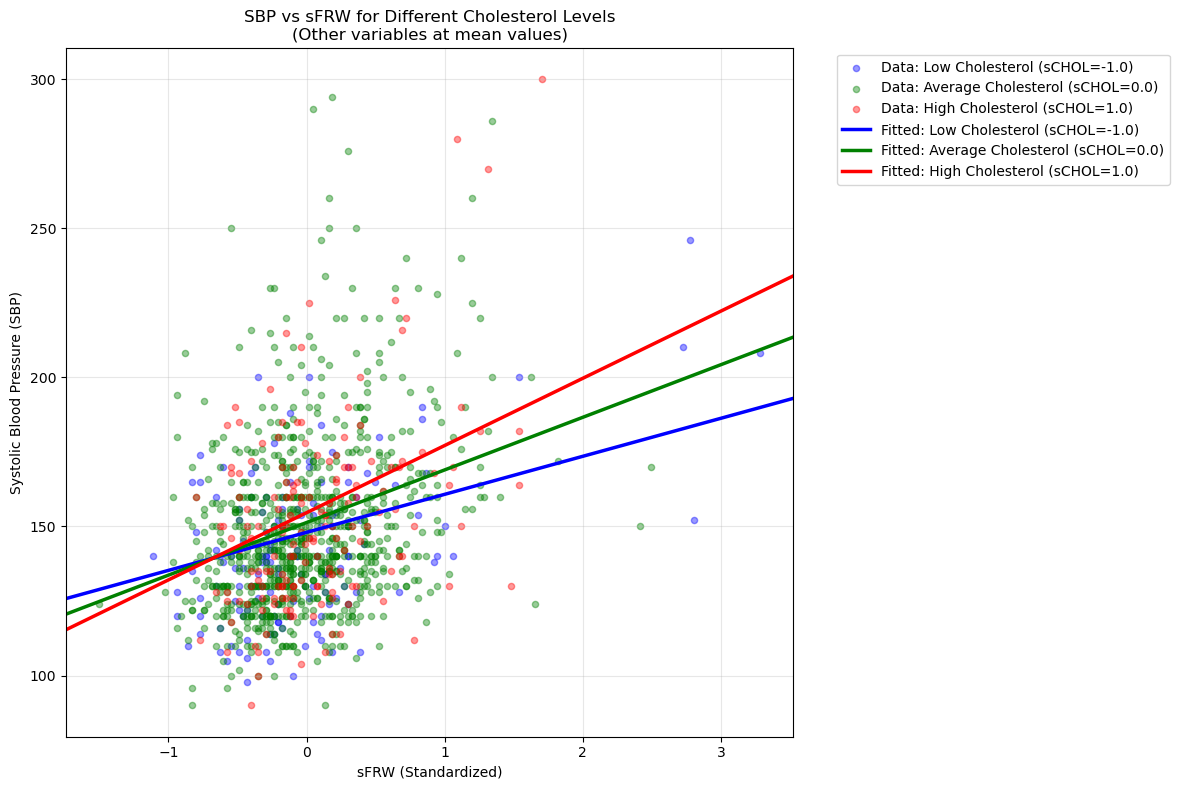


Model includes sCIG: True
sCIG coefficient: 3.7733
Found interaction sFRW:sCIG: 3.6765
Total parameters: 16


In [174]:
# exercise 8
# Put your solution here!

# Create the enhanced model with sCIG and all interactions
fit = smf.ols('SBP ~ (sFRW + SEX + sCHOL + sAGE + sCIG)**2', data=fram).fit()

# Print model summary
print("Enhanced Model Summary:")
print("=" * 50)
print(fit.summary())

# Find the most important variable by absolute coefficient value
main_effects = ['sFRW', 'SEX', 'sCHOL', 'sAGE', 'sCIG']
most_important = None
max_coeff = 0

for var in main_effects:
    if var in fit.params:
        coeff = abs(fit.params[var])
        if coeff > max_coeff:
            max_coeff = coeff
            most_important = var

# If no most important found, default to sFRW
if most_important is None:
    most_important = 'sFRW'

print(f"\nMost important explanatory variable: {most_important}")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Cholesterol levels and colors
chol_levels = [-1.0, 0.0, 1.0]
chol_labels = ['Low Cholesterol (sCHOL=-1.0)', 'Average Cholesterol (sCHOL=0.0)', 'High Cholesterol (sCHOL=1.0)']
colors = ['blue', 'green', 'red']

# Create scatter plots for each cholesterol level
for i, (chol_level, chol_label, color) in enumerate(zip(chol_levels, chol_labels, colors)):
    # Filter data points near this cholesterol level
    chol_tolerance = 0.4
    chol_mask = (fram['sCHOL'] >= chol_level - chol_tolerance) & (fram['sCHOL'] <= chol_level + chol_tolerance)
    subset_data = fram[chol_mask]
    
    if len(subset_data) > 0:
        plt.scatter(subset_data[most_important], subset_data['SBP'], 
                   color=color, alpha=0.4, s=20, 
                   label=f'Data: {chol_label}')

# For each cholesterol level, calculate and plot the fitted line using abline_plot
for i, (chol_level, chol_label, color) in enumerate(zip(chol_levels, chol_labels, colors)):
    
    # Calculate effective intercept (other variables at mean = 0)
    intercept = fit.params['Intercept']
    
    # Add cholesterol effect to intercept
    if 'sCHOL' in fit.params:
        intercept += fit.params['sCHOL'] * chol_level
    
    # Calculate effective slope for the most important variable
    slope = 0
    if most_important in fit.params:
        slope = fit.params[most_important]
    
    # Add interaction effect between most important variable and cholesterol
    interaction_terms = [f'{most_important}:sCHOL', f'sCHOL:{most_important}']
    for interaction_term in interaction_terms:
        if interaction_term in fit.params:
            slope += fit.params[interaction_term] * chol_level
            break
    
    # Use abline_plot for the fitted line
    abline_plot(intercept, slope, ax=ax, color=color, linewidth=2.5,
                label=f'Fitted: {chol_label}')

# Add labels and formatting
plt.xlabel(f'{most_important} (Standardized)')
plt.ylabel('Systolic Blood Pressure (SBP)')
plt.title(f'SBP vs {most_important} for Different Cholesterol Levels\n(Other variables at mean values)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel includes sCIG: {'sCIG' in fit.params}")
if 'sCIG' in fit.params:
    print(f"sCIG coefficient: {fit.params['sCIG']:.4f}")

# Check for sFRW:sCIG interaction
interaction_found = False
for term in fit.params.index:
    if ('sFRW' in term and 'sCIG' in term and ':' in term):
        print(f"Found interaction {term}: {fit.params[term]:.4f}")
        interaction_found = True
        break

print(f"Total parameters: {len(fit.params)}")

How does the model and its accuracy look?

***

The model looks fine, and the accuracy is consistent with what we would expect. Higher weight is clearly associated with higher SBP. Also, it makes sense that higher cholesterol levels amplify weight's impact on blood pressure more than lower cholesterol levels. For example, high cholesterol makes arteries less flexible so when the weight increases blood volume the stiffer arteries make more traffic for the blood hence increasing blood pressure. So the weight's effect is multiplied when the cholesterol level is higher. 

***

# Logistic regression

In [175]:
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

We will continue predicting high blood pressure by taking in some continuous background variables, such as the age.

Recreate the model `HIGH_BP ~ sFRW + SEX + SEX:sFRW` presented in the introduction. Make sure, that you get the same results. Use name `fit` for the fitted model. Compute and store the error rate into variable `error_rate_orig`.

In [176]:
# exercise 9
# Put your solution here!

# Create HIGH_BP using the correct medical definition:
# High BP if SBP >= 140 OR DBP >= 90
fram["HIGH_BP"] = ((fram.SBP >= 140) | (fram.DBP >= 90)).astype(int)

#using smf.glm now instead of smf.ols
fit = smf.glm('HIGH_BP ~ sFRW + SEX + SEX:sFRW', 
                  data=fram, 
                  family=sm.families.Binomial()).fit()
print(fit.summary())
error_rate_orig = np.mean(((fit.fittedvalues < 0.5) & fram.HIGH_BP) | 
                    ((fit.fittedvalues > 0.5) & ~fram.HIGH_BP))


                 Generalized Linear Model Regression Results                  
Dep. Variable:                HIGH_BP   No. Observations:                 1394
Model:                            GLM   Df Residuals:                     1390
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -856.87
Date:                Tue, 26 Aug 2025   Deviance:                       1713.7
Time:                        14:39:41   Pearson chi2:                 1.39e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06351
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.7631      0.082  

Add the `sAGE` variable and its interactions. Check the prediction accuracy of the model and compare it to the previous model. Store the prediction accuracy to variable `error_rate`.

In [177]:
# exercise 10
# Put your solution here!

fram["HIGH_BP"] = ((fram.SBP >= 140) | (fram.DBP >= 90)).astype(int)

#using smf.glm now instead of smf.ols
fit = smf.glm('HIGH_BP ~ sFRW + SEX + sAGE + SEX:sFRW + sFRW:sAGE + SEX:sAGE', 
                  data=fram, 
                  family=sm.families.Binomial()).fit()
print(fit.summary())
error_rate = np.mean(((fit.fittedvalues < 0.5) & fram.HIGH_BP) | 
                    ((fit.fittedvalues > 0.5) & ~fram.HIGH_BP))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                HIGH_BP   No. Observations:                 1394
Model:                            GLM   Df Residuals:                     1387
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -845.51
Date:                Tue, 26 Aug 2025   Deviance:                       1691.0
Time:                        14:39:45   Pearson chi2:                 1.39e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.07865
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.8079      0.084  

Visualize the predicted probability of high blood pressure as the function of weight. Remember to use normalized values (`rescale`) also for those variables that are not included in the visualization, so that sensible values are used for them (data average). Draw two figures with altogether six curves: young, middle aged, and old women; and young, middle aged, and old men. Use `plt.subplots`. (Plotting works in similar fashion as in the introduction. The argument factors need, however, be changed as in the example about visualisation of continuous variable.) 

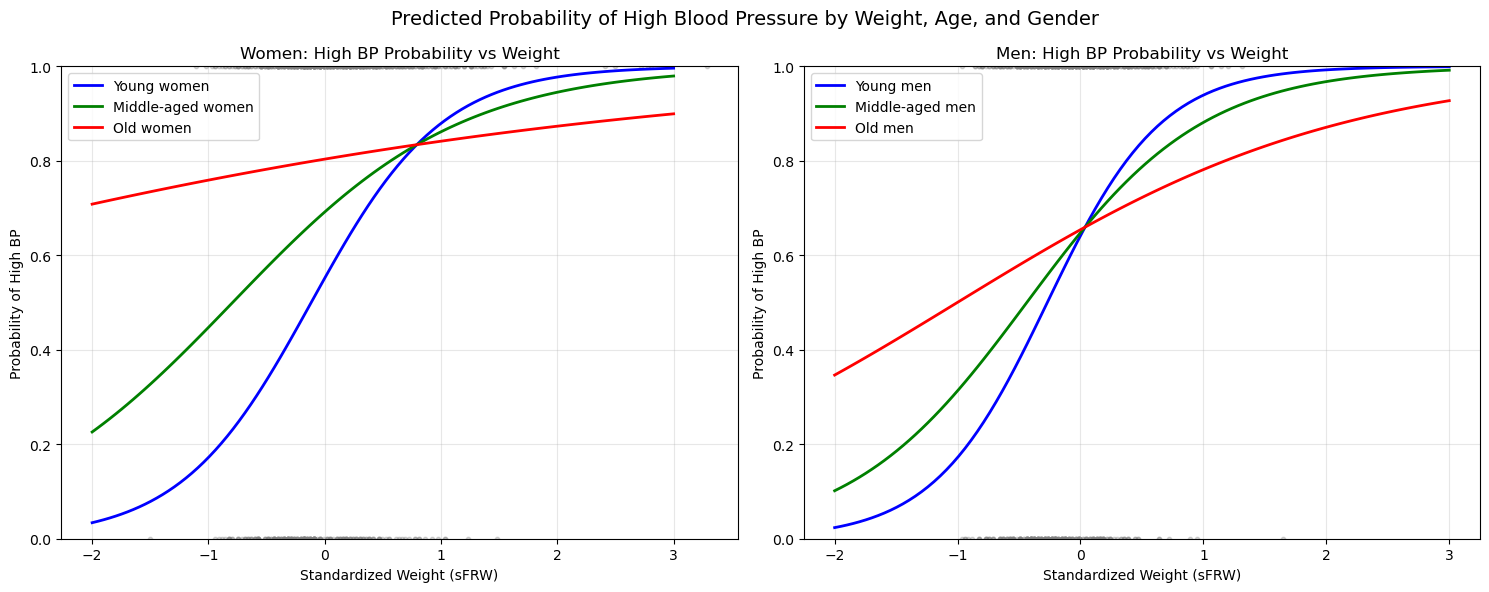

In [178]:
# exercise 11
# Put your solution here!
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

# Put your solution here!
sfrw_range = np.linspace(-2, 3, 100)  # Cover typical range of standardized weight

# Age groups: young (-1.0), middle aged (0.0), old (1.0)
age_groups = [-1.0, 0.0, 1.0]
age_labels = ['Young', 'Middle-aged', 'Old']
colors = ['blue', 'green', 'red']

# Create subplots: 1 row, 2 columns (women and men)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for WOMEN (left subplot)
ax1.set_title('Women: High BP Probability vs Weight')

# First, scatter plot the actual data points for women
women_data = fram[fram['SEX'] == 'female']
women_high_bp = ((women_data.SBP >= 140) | (women_data.DBP >= 90)).astype(int)
ax1.scatter(women_data['sFRW'], women_high_bp, alpha=0.3, s=10, color='gray')

# Then plot the prediction curves (this should make 3 plot calls)
for i, (age, label, color) in enumerate(zip(age_groups, age_labels, colors)):
    # Create prediction DataFrame for women at this age
    pred_data_women = pd.DataFrame({
        'sFRW': sfrw_range,
        'SEX': 'female',  # Women
        'sAGE': age       # Current age group
    })
    
    # Get predicted probabilities
    prob_women = fit.predict(pred_data_women)
    
    # Plot the prediction curve using plot()
    ax1.plot(sfrw_range, prob_women, color=color, linewidth=2, label=f'{label} women')

ax1.set_xlabel('Standardized Weight (sFRW)')
ax1.set_ylabel('Probability of High BP')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot for MEN (right subplot)
ax2.set_title('Men: High BP Probability vs Weight')

# First, scatter plot the actual data points for men
men_data = fram[fram['SEX'] == 'male']
men_high_bp = ((men_data.SBP >= 140) | (men_data.DBP >= 90)).astype(int)
ax2.scatter(men_data['sFRW'], men_high_bp, alpha=0.3, s=10, color='gray')

# Then plot the prediction curves (this should make 3 more plot calls)
for i, (age, label, color) in enumerate(zip(age_groups, age_labels, colors)):
    # Create prediction DataFrame for men at this age
    pred_data_men = pd.DataFrame({
        'sFRW': sfrw_range,
        'SEX': 'male',    # Men
        'sAGE': age       # Current age group
    })
    
    # Get predicted probabilities
    prob_men = fit.predict(pred_data_men)
    
    # Plot the prediction curve using plot()
    ax2.plot(sfrw_range, prob_men, color=color, linewidth=2, label=f'{label} men')

ax2.set_xlabel('Standardized Weight (sFRW)')
ax2.set_ylabel('Probability of High BP')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Overall title
fig.suptitle('Predicted Probability of High Blood Pressure by Weight, Age, and Gender', fontsize=14)
plt.tight_layout()
plt.show()

How do the models with different ages and genders differ from each other?

***
You can clearly tell that different ages within the same gender make significant differences. Young and middle aged men and women are at a low-risk baseline but are very highly affected by weight. Increased weight increases high blood pressure risk greatly and even puts them at higher risk than elderly men and women of the same standardized weight once the threshold value (about 0.7 for women and 0.1 for men) is reached.

As for across genders, men appear to have lower (predicted) probabilities of high blood pressure when the standardized weight is below about 1, women appear to have lower (predicted) probabilities of high blood pressure when standardized weight is greater than about 1. But, generally, it does appear men are usually at lower risk for high blood pressure based on weight than women.  
***

Create here a helper function `train_test_split` that gets a DataFrame as parameter and return a pair of DataFrames: one for training and the second for testing. 
The function should get parameters in the following way:
```python
train_test_split(df, train_fraction=0.8)
```
The data should be split randomly to training and testing DataFrames so that `train_fraction` fraction of data should go into the training set. Use the `sample` method of the DataFrame.

In [179]:
# exercise 12
# Put your solution here!
def train_test_split(df, train_fraction=0.8):
    """
    Split a DataFrame into training and testing sets using numpy random sampling.
    """
    # Calculate the number of samples for training
    n_train = int(len(df) * train_fraction)
    
    # Use numpy to randomly choose indices
    all_indices = df.index.values
    train_indices = np.random.choice(all_indices, size=n_train, replace=False)
    
    # Create training and testing sets
    train_df = df.loc[train_indices]
    test_df = df.drop(train_indices)
    
    return train_df, test_df


Check the prediction accuracy of your model using cross validation. Use 100-fold cross validation and training_fraction 0.8.

In [197]:
# exercise 13
# Put your solution here!

error_model = []
error_null = []

np.random.seed(1)
for i in range(100):
    train, test = train_test_split(fram)
    
    fit = smf.glm(formula="HIGH_BP ~ sFRW + sAGE + SEX + sFRW:SEX + sAGE:SEX + sFRW:sAGE", 
                  data=train,
                  family=sm.families.Binomial(sm.families.links.Logit())).fit()
    
    pred = fit.predict(test, transform=True)
    
    error_rate = np.mean(((pred < 0.5) & (test.HIGH_BP==1)) |
                         ((pred > 0.5) & (test.HIGH_BP==0)))
    error_model.append(error_rate)
    
    error_null.append((1 - test.HIGH_BP).mean())

## Predicting coronary heart disease

Let us use again the same data to learn a model for the occurrence of coronary heart disease. We will use logistic regression to predict whether a patient *sometimes* shows symptoms of coronary heart disease. For this, add to the data a binary variable `hasCHD`, that describes the event (`CHD > 0`). The binary variable `hadCHD` can get only two values: 0 or 1. As a sanity check, compute the mean of this variable, which tells the number of positive cases.

In [206]:
# exercise 14
# Put your solution here!
# Create binary variable hasCHD based on CHD > 0
fram["hasCHD"] = (fram.CHD > 0).astype(int)

# Sanity check - compute the mean (proportion of positive cases)
mean_hasCHD = fram.hasCHD.mean()
print(f"Mean of hasCHD: {mean_hasCHD:.4f}")
print(f"Number of positive cases: {fram.hasCHD.sum()}")
print(f"Total cases: {len(fram)}")
print(f"Proportion with CHD: {mean_hasCHD:.1%}")

Mean of hasCHD: 0.2202
Number of positive cases: 307
Total cases: 1394
Proportion with CHD: 22.0%


Next, form a logistic regression model for variable `hasCHD` by using variables sCHOL, sCIG, and sFRW, and their interactions as explanatory variables. Store the fitted model to variable `fit`. Compute the prediction accuracy of the model, store it to variable `error_rate`.

In [207]:
# exercise 15
# Put your solution here!

fit = smf.glm(
    formula="hasCHD ~ sCHOL + sCIG + sFRW + sCHOL:sCIG + sCHOL:sFRW + sCIG:sFRW",
    data=fram,
    family=sm.families.Binomial(sm.families.links.Logit())
).fit()

# Get predictions
pred = fit.predict(fram, transform=True)

# Compute prediction accuracy (error rate)
error_rate = np.mean(((pred < 0.5) & (fram.hasCHD == 1)) |
                     ((pred >= 0.5) & (fram.hasCHD == 0)))

print(f"Error rate: {error_rate:.4f}")
print(f"Accuracy: {1 - error_rate:.4f}")

# Optional: Show model summary
print(fit.summary())


Error rate: 0.2202
Accuracy: 0.7798
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 hasCHD   No. Observations:                 1394
Model:                            GLM   Df Residuals:                     1387
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -721.19
Date:                Tue, 26 Aug 2025   Deviance:                       1442.4
Time:                        23:21:38   Pearson chi2:                 1.39e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01950
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1

Visualize the model by using the most important explanator on the x axis. Visualize both the points (with `plt.scatter`)
and the logistic curve (with `plt.plot`).

Most important variable: sCIG
Coefficient: 0.4613


C:\Users\daifa\AppData\Local\Temp\ipykernel_4016\2622323964.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept = fit.params[0]


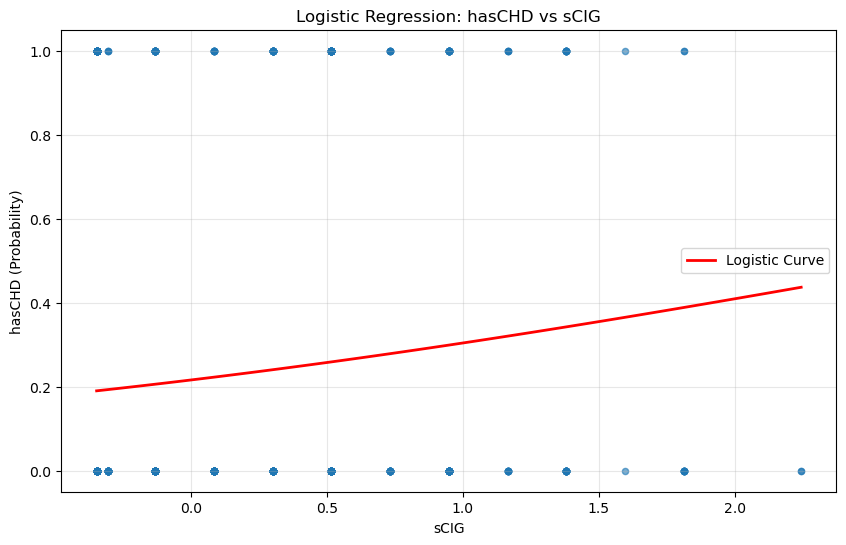


All coefficients:
sCHOL: 0.3324
sCIG: 0.4613
sFRW: 0.4404
sCHOL:sCIG: -0.1022
sCHOL:sFRW: 0.1359
sCIG:sFRW: 0.1646


In [208]:
# exercise 16
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))
# Put your solution here!

# Get the model coefficients (excluding intercept)
coefficients = fit.params[1:]  # Skip intercept
abs_coefficients = np.abs(coefficients)

# Find the most important variable (largest absolute coefficient)
most_important_var = abs_coefficients.idxmax()
print(f"Most important variable: {most_important_var}")
print(f"Coefficient: {coefficients[most_important_var]:.4f}")

# Get the data for the most important variable
x_data = fram[most_important_var]
y_data = fram['hasCHD']

# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot of the data points
plt.scatter(x_data, y_data, alpha=0.6, s=20)

# Create smooth x values for the logistic curve
x_smooth = np.linspace(x_data.min(), x_data.max(), 100)

# For the logistic curve, we need the linear combination
# Using only the most important variable (simplified model for visualization)
intercept = fit.params[0]
coef = fit.params[most_important_var]

# Calculate the linear combination
linear_combo = intercept + coef * x_smooth

# Apply logistic function
y_smooth = logistic(linear_combo)

# Plot the logistic curve
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Logistic Curve')

plt.xlabel(most_important_var)
plt.ylabel('hasCHD (Probability)')
plt.title(f'Logistic Regression: hasCHD vs {most_important_var}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print coefficient information
print(f"\nAll coefficients:")
for var, coef in coefficients.items():
    print(f"{var}: {coef:.4f}")

Is the prediction accuracy of the model good or bad? Can we expect to have practical use of the model?
***
From exercise 15, we know the accuracy of the model is almost 78%, which is pretty decent. However, the practical use of the model appears low because the logistic curve in exercise 16 shows predicted probabilities only under 0.5. This means that no high confidence in the predictions. Also, the error rate being about 22%, while pretty decent as I said, is a little high for practical use in the medical field on human patients and could definentely lead to ethical issues. 
***

If a person has cholestherol 200, smokes 17 cigarets per day, and has weight 100, then what is the probability that he/she sometimes shows signs of coronal hear disease? Note that the model expects normalized values. Store the normalized values to dictionary called `point`. Store the probability in variable `predicted`.

In [211]:
# exercise 17
# Put your solution here!

# Raw values
cholesterol = 200
cigarettes = 17
weight = 100

# Manually normalize using the original data statistics
# (This is how rescale works: (x - mean) / (2 * std))
sCHOL_val = (cholesterol - fram.CHOL.mean()) / (2 * fram.CHOL.std())
sCIG_val = (cigarettes - fram.CIG.mean()) / (2 * fram.CIG.std())
sFRW_val = (weight - fram.FRW.mean()) / (2 * fram.FRW.std())

# Store normalized values in dictionary
point = {
    'sCHOL': sCHOL_val,
    'sCIG': sCIG_val, 
    'sFRW': sFRW_val
}

print(f"Normalized values:")
print(f"sCHOL: {point['sCHOL']:.4f}")
print(f"sCIG: {point['sCIG']:.4f}")
print(f"sFRW: {point['sFRW']:.4f}")

# Create a DataFrame with the normalized values for prediction
point_df = pd.DataFrame([point])

# Use the fitted model to predict probability
predicted = fit.predict(point_df, transform=True)[0]

print(f"\nPredicted probability of CHD: {predicted:.4f} ({predicted:.1%})")

Normalized values:
sCHOL: -0.3741
sCIG: 0.3872
sFRW: -0.1511

Predicted probability of CHD: 0.2162 (21.6%)
